In [8]:
!pip3 install numpy


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip


In [9]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE_PATH = "/Users/dhairyabhatt/code_dir/Data analytics projects/world_health/data"
OUTPUT_PATH = os.path.join(BASE_PATH, "phase3_outputs")

In [10]:
# Cell 1 — Load and inspect
import pandas as pd

q28 = pd.read_csv(os.path.join(OUTPUT_PATH,'q28_ntd_quartile.csv'))
print(q28.shape)
q28.head()


(193, 6)


,country,count_2010,count_2018,abs_change,pct_change,burden_q
0,Afghanistan,12246738.0,14834701.0,2587963.0,21.131856,Q4_highest
1,Albania,61.0,47.0,-14.0,-22.950820,Q1_lowest
2,Algeria,10260.0,10909.0,649.0,6.325536,Q2
3,Andorra,0.0,0.0,0.0,NaN,Q1_lowest
4,Angola,15879207.0,15220708.0,-658499.0,-4.146926,Q4_highest


In [11]:
# Cell 2 — Quartile-level summary stats
quartile_summary = (
    q28.groupby('burden_q')[['count_2010', 'count_2018', 'abs_change', 'pct_change']]
    .agg(['mean', 'median', 'std', 'count'])
)
quartile_summary

count_2010                                    count_2018  \
                    mean      median           std count          mean   
burden_q                                                                 
Q1_lowest   1.306122e+01         6.0  1.607069e+01    49  8.060612e+02   
Q2          2.083731e+04      5842.0  2.979917e+04    48  6.636231e+04   
Q3          1.139850e+06    767011.5  1.105305e+06    48  1.143591e+06   
Q4_highest  4.303218e+07  15255512.5  1.213221e+08    48  3.510704e+07   

                                              abs_change             \
                median           std count          mean     median   
burden_q                                                              
Q1_lowest          1.0  5.303706e+03    49  7.930000e+02       -1.0   
Q2               369.5  2.629685e+05    48  4.552500e+04     -354.5   
Q3            485770.5  1.570532e+06    48  3.740812e+03  -119633.0   
Q4_highest  12381417.5  1.008354e+08    48 -7.925141e+06 -1562255.0   

                                 pct_change                                 
                     std count         mean     median           std count  
burden_q                                                                    
Q1_lowest   5.301160e+03    49          inf -50.000000           NaN    39  
Q2          2.580842e+05    48  5914.447543 -77.439991  40463.623775    48  
Q3          1.539843e+06    48    64.914587 -19.608535    448.581989    48  
Q4_highest  2.354423e+07    48    -6.506258 -12.868417     47.303519    48

In [12]:
# Cell 3 — Kruskal-Wallis: is pct_change distribution different across quartiles?
from scipy.stats import kruskal

groups = [q28.loc[q28['burden_q'] == q, 'pct_change'].dropna() for q in sorted(q28['burden_q'].unique())]
stat, p = kruskal(*groups)
print(f"Kruskal-Wallis H = {stat:.3f}, p = {p:.4f}")

Kruskal-Wallis H = 6.460, p = 0.0913


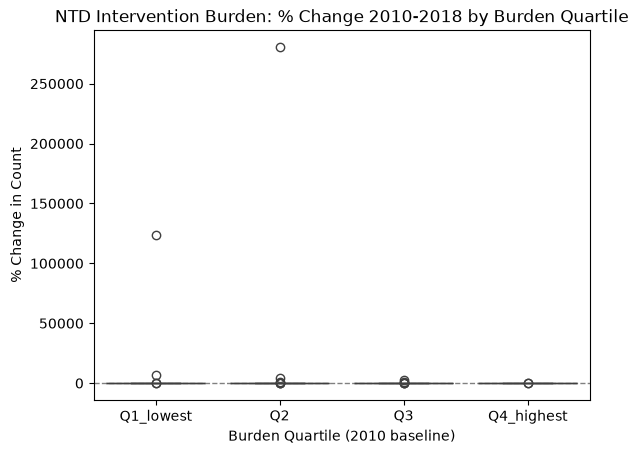

In [13]:
# Cell 4 — Boxplot of progress by quartile
import matplotlib.pyplot as plt
import seaborn as sns

order = sorted(q28['burden_q'].unique())
sns.boxplot(data=q28, x='burden_q', y='pct_change', order=order)
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.title('NTD Intervention Burden: % Change 2010-2018 by Burden Quartile')
plt.xlabel('Burden Quartile (2010 baseline)')
plt.ylabel('% Change in Count')
plt.show()

In [16]:
# Cell 4 — Median / IQR summary of pct_change by quartile
summary = q28.groupby('burden_q')['pct_change'].agg(
    median='median',
    q1=lambda x: x.quantile(0.25),
    q3=lambda x: x.quantile(0.75),
    n='count'
)
summary['iqr'] = summary['q3'] - summary['q1']
summary = summary.reindex(sorted(q28['burden_q'].unique()))
summary

,median,q1,q3,n,iqr
burden_q,,,,,
Q1_lowest,-50.000000,-94.365079,23.064687,39,117.429767
Q2,-77.439991,-98.936352,19.278763,48,118.215114
Q3,-19.608535,-85.859463,11.484482,48,97.343946
Q4_highest,-12.868417,-36.457181,7.292992,48,43.750173


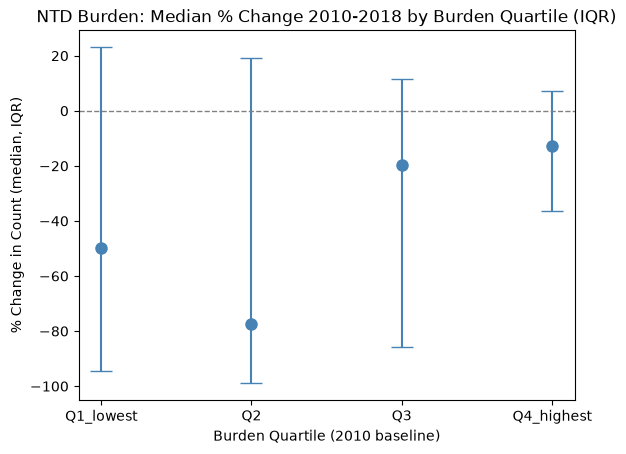

In [17]:
# Cell 4b — Plot median with IQR error bars by quartile
import matplotlib.pyplot as plt

order = sorted(q28['burden_q'].unique())
plot_data = summary.loc[order]

# Asymmetric error bars: distance from median down to q1, and up to q3
lower_err = plot_data['median'] - plot_data['q1']
upper_err = plot_data['q3'] - plot_data['median']

plt.errorbar(
    x=order,
    y=plot_data['median'],
    yerr=[lower_err, upper_err],
    fmt='o',
    capsize=8,
    markersize=8,
    color='steelblue',
    ecolor='steelblue'
)
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.title('NTD Burden: Median % Change 2010-2018 by Burden Quartile (IQR)')
plt.xlabel('Burden Quartile (2010 baseline)')
plt.ylabel('% Change in Count (median, IQR)')
plt.show()

In [14]:
# Cell 5 — Spearman correlation: continuous check beyond quartile binning
from scipy.stats import spearmanr

corr, p_corr = spearmanr(q28['count_2010'], q28['pct_change'])
print(f"Spearman r = {corr:.3f}, p = {p_corr:.4f}")

Spearman r = nan, p = nan


In [15]:
# Cell 6 — Outlier identification
q4 = q28[q28['burden_q'] == 'Q4'].sort_values('pct_change')
print("Q4 (highest burden) — fastest improvers:")
print(q4.head(5)[['country', 'count_2010', 'count_2018', 'pct_change']])
print("\nQ4 (highest burden) — slowest / worsened:")
print(q4.tail(5)[['country', 'count_2010', 'count_2018', 'pct_change']])

q1 = q28[q28['burden_q'] == 'Q1'].sort_values('pct_change')
print("\nQ1 (lowest burden) — fastest improvers:")
print(q1.head(5)[['country', 'count_2010', 'count_2018', 'pct_change']])
print("\nQ1 (lowest burden) — stagnant / worsened:")
print(q1.tail(5)[['country', 'count_2010', 'count_2018', 'pct_change']])

Q4 (highest burden) — fastest improvers:
Empty DataFrame
Columns: [country, count_2010, count_2018, pct_change]
Index: []

Q4 (highest burden) — slowest / worsened:
Empty DataFrame
Columns: [country, count_2010, count_2018, pct_change]
Index: []

Q1 (lowest burden) — fastest improvers:
Empty DataFrame
Columns: [country, count_2010, count_2018, pct_change]
Index: []

Q1 (lowest burden) — stagnant / worsened:
Empty DataFrame
Columns: [country, count_2010, count_2018, pct_change]
Index: []
